In [ ]:
import torch.nn as nn
import torch
from torch_geometric.nn import GATConv, BatchNorm
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

class GATRNN(nn.Module):
    def __init__(self, num_nodes, num_node_features, num_edge_features, num_weather_features, hidden_size, lstm_hidden_size=64, num_heads=8, num_targets_per_node=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.gat_conv = GATConv(num_node_features, hidden_size, heads=num_heads, concat=False, edge_dim=num_edge_features)
        self.gat_linear = nn.Linear(hidden_size, 1)
        self.gat_activation = nn.Tanh()
        self.num_targets_per_node = num_targets_per_node

        # self.batch_norm1 = BatchNorm(hidden_size)
        self.lstm = nn.LSTM(input_size=3 * num_nodes, hidden_size=lstm_hidden_size, batch_first=True)
        self.lstm_linear = nn.Linear(lstm_hidden_size, num_nodes * num_targets_per_node)
        self.lstm_activation = nn.Tanh()
        
 
    def forward(self, node_features, edge_features, node_dynamic_features, edge_index):
        if node_dynamic_features.dim() == 2:
            node_dynamic_features = node_dynamic_features.unsqueeze(0)

        x1 = self.gat_conv(node_features, edge_index, edge_features)
        x1 = self.gat_linear(x1)
        x1 = self.gat_activation(x1).squeeze(-1)  # [num_nodes]

        batch_size = node_dynamic_features.size(0)
        seq_len = node_dynamic_features.size(2)
        dynamic_features = node_dynamic_features.view(batch_size, self.num_nodes, 2, seq_len)
        static_feature = x1.view(1, self.num_nodes, 1, 1).expand(batch_size, -1, -1, seq_len)
        lstm_input = torch.cat((static_feature, dynamic_features), dim=2)
        lstm_input = lstm_input.permute(0, 3, 1, 2).reshape(batch_size, seq_len, 3 * self.num_nodes)

        x3, _ = self.lstm(lstm_input)
        x4 = self.lstm_linear(x3)
        output = self.lstm_activation(x4)

        return output


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

node_data = pd.read_csv('Florida_nodeList.csv')
edge_data = pd.read_csv('Florida_edgeList.csv')
rain_features = pd.read_csv(r'C:\Users\ke119419\Desktop\EEL6812\FinalProject\EEL6812_Final_Project\Florida\Rain\nodes\weatherEvent.csv')
wind_features = pd.read_csv(r'C:\Users\ke119419\Desktop\EEL6812\FinalProject\EEL6812_Final_Project\Florida\Wind\nodes\weatherEvent.csv')

node_features = node_data['elevation']
edge_features = edge_data['weight']

rain_data = np.array(rain_features)
wind_data = np.array(wind_features)

weather_data = np.zeros((2 * rain_features.shape[0], rain_features.shape[1]))
for i in range(rain_features.shape[0]):
    weather_data[2*i, :] = rain_data[i, :]
    weather_data[2*i+1, :] = wind_data[i, :]

edge_index = np.array([
    np.array(edge_data['source']-1),
    np.array(edge_data['target']-1)
])

node_features = torch.tensor(node_features.values.reshape(-1, 1), dtype=torch.float32, device=device)
edge_features = torch.tensor(edge_features.values.reshape(-1, 1), dtype=torch.float32, device=device)
weather_data = torch.tensor(weather_data, dtype=torch.float32, device=device)
edge_index = torch.tensor(edge_index, dtype=torch.long, device=device)

print("device:", device)
print("node_features:", node_features.shape)   # [N, 1]
print("edge_features:", edge_features.shape)   # [E, 1]
print("edge_index:", edge_index.shape)         # [2, E]
print("weather_data:", weather_data.shape)

model = GATRNN(
    num_nodes=rain_features.shape[0],
    num_node_features=1,
    num_edge_features=1,
    num_weather_features=2,
    hidden_size=32,
    lstm_hidden_size=64,
    num_heads=8,
    num_targets_per_node=2
).to(device)


x2 = torch.zeros((3*rain_features.shape[0], rain_features.shape[1]), device=device)
        
for i in range(rain_features.shape[0]):

    x2[3*i,:] = 0 * x2[3*i,:] + node_features[i]
    x2[3*i+1,:] = weather_data[2*i,:]
    x2[3*i+2,:] = weather_data[2*i+1,:]





output = model(node_features, edge_features, weather_data, edge_index)




device: cuda
node_features: torch.Size([2477, 1])
edge_features: torch.Size([7803, 1])
edge_index: torch.Size([2, 7803])
weather_data: torch.Size([4954, 49])


num_windows: 26
train_window_count: 20
train_series_end: 43
train shape: torch.Size([20, 4954, 12]) -> torch.Size([20, 12, 4954])
val shape: torch.Size([6, 4954, 12]) -> torch.Size([6, 12, 4954])
train samples: 20, val samples: 6
batch size: 16
normalized train input mean: -0.1257, std: 0.4293
normalized train target mean: -0.1454, std: 0.0805
normalized val input mean: -0.1488, std: 0.0744
normalized val target mean: -0.1284, std: 0.1281
Epoch 001 | Train MSE: 0.001397 | Val MSE: 0.005718
Epoch 010 | Train MSE: 0.000610 | Val MSE: 0.005230
Epoch 020 | Train MSE: 0.000589 | Val MSE: 0.004724
Epoch 030 | Train MSE: 0.000587 | Val MSE: 0.004870
Epoch 040 | Train MSE: 0.000550 | Val MSE: 0.004845
Epoch 050 | Train MSE: 0.000533 | Val MSE: 0.004823
Epoch 060 | Train MSE: 0.000546 | Val MSE: 0.004837
Epoch 070 | Train MSE: 0.000556 | Val MSE: 0.004802
Epoch 080 | Train MSE: 0.000543 | Val MSE: 0.004521
Epoch 090 | Train MSE: 0.000548 | Val MSE: 0.004375
Epoch 100 | Train MSE: 0.000458 | Val

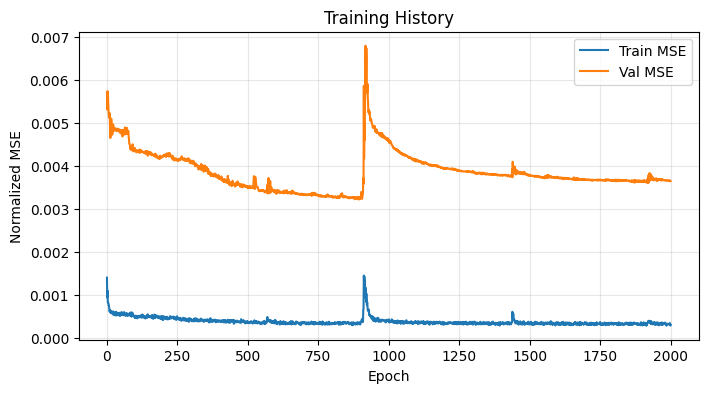

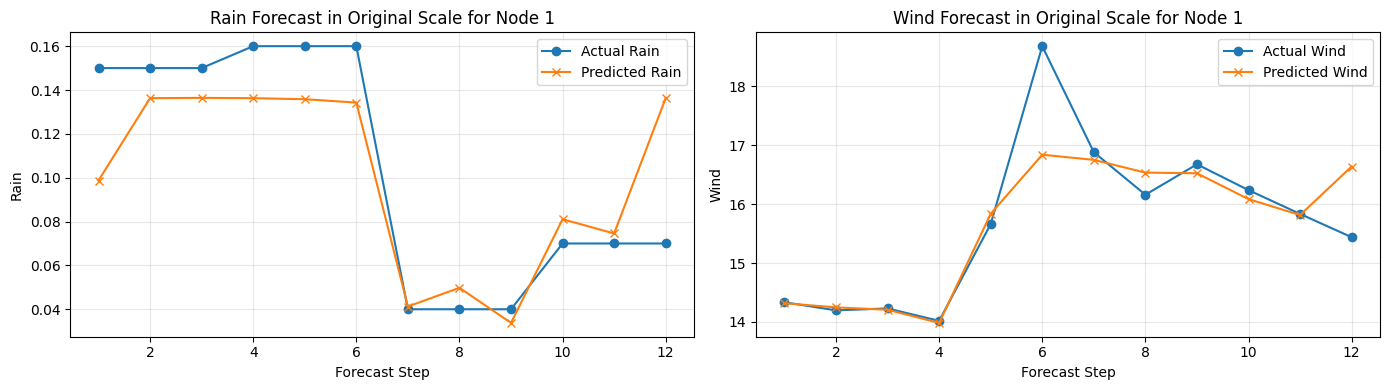

In [37]:
from torch.utils.data import TensorDataset, DataLoader

input_steps = 12
output_steps = 12
num_timesteps = rain_features.shape[1]
eps = 1e-6

future_weather = []
for i in range(rain_features.shape[0]):
    future_weather.append(rain_data[i, :])
    future_weather.append(wind_data[i, :])

future_weather = torch.tensor(np.array(future_weather), dtype=torch.float32)  # [2 * num_nodes, T]
weather_data_cpu = weather_data.detach().cpu()
target_series = future_weather.T  # [T, 2 * num_nodes]

num_windows = num_timesteps - input_steps - output_steps + 1
train_window_count = max(1, int(0.8 * num_windows))
train_window_count = min(train_window_count, num_windows - 1) if num_windows > 1 else 1
train_series_end = train_window_count - 1 + input_steps + output_steps

train_input_series = weather_data_cpu[:, :train_series_end]
train_target_series = target_series[:train_series_end, :]

input_mean = train_input_series.mean(dim=1, keepdim=True)
input_std = train_input_series.std(dim=1, keepdim=True).clamp_min(eps)
target_mean = train_target_series.mean(dim=0, keepdim=True)
target_std = train_target_series.std(dim=0, keepdim=True).clamp_min(eps)

normalized_input_series = (weather_data_cpu - input_mean) / input_std
normalized_target_series = (target_series - target_mean) / target_std

all_inputs = []
all_targets = []
for start_idx in range(num_windows):
    target_start = start_idx + input_steps
    all_inputs.append(normalized_input_series[:, start_idx:start_idx + input_steps])
    all_targets.append(normalized_target_series[target_start:target_start + output_steps, :])

X = torch.stack(all_inputs)
y = torch.stack(all_targets)

X_train_norm = X[:train_window_count]
y_train_norm = y[:train_window_count]
X_val_norm = X[train_window_count:]
y_val_norm = y[train_window_count:]

train_dataset = TensorDataset(X_train_norm, y_train_norm)
val_dataset = TensorDataset(X_val_norm, y_val_norm)

batch_size = min(16, len(train_dataset)) if len(train_dataset) > 0 else 1
loader_kwargs = {
    'batch_size': batch_size,
    'pin_memory': device.type == 'cuda'
}

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 2000
train_losses = []
val_losses = []

print(f'num_windows: {num_windows}')
print(f'train_window_count: {train_window_count}')
print(f'train_series_end: {train_series_end}')
print(f'train shape: {X_train_norm.shape} -> {y_train_norm.shape}')
print(f'val shape: {X_val_norm.shape} -> {y_val_norm.shape}')
print(f'train samples: {len(train_dataset)}, val samples: {len(val_dataset)}')
print(f'batch size: {batch_size}')
print(f'normalized train input mean: {X_train_norm.mean().item():.4f}, std: {X_train_norm.std().item():.4f}')
print(f'normalized train target mean: {y_train_norm.mean().item():.4f}, std: {y_train_norm.std().item():.4f}')
if len(val_dataset) > 0:
    print(f'normalized val input mean: {X_val_norm.mean().item():.4f}, std: {X_val_norm.std().item():.4f}')
    print(f'normalized val target mean: {y_val_norm.mean().item():.4f}, std: {y_val_norm.std().item():.4f}')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch_inputs, batch_targets in train_loader:
        batch_inputs = batch_inputs.to(device, non_blocking=True)
        batch_targets = batch_targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        preds = model(node_features, edge_features, batch_inputs, edge_index)
        loss = criterion(preds[:, -output_steps:, :], batch_targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_inputs, batch_targets in val_loader:
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            batch_targets = batch_targets.to(device, non_blocking=True)
            preds = model(node_features, edge_features, batch_inputs, edge_index)
            loss = criterion(preds[:, -output_steps:, :], batch_targets)
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else float('nan')
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch + 1:03d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('Normalized MSE')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if len(val_dataset) > 0:
    model.eval()
    sample_idx = 0
    node_idx = 0

    sample_input = X_val_norm[sample_idx:sample_idx + 1].to(device)
    sample_target_norm = y_val_norm[sample_idx].to(device)

    with torch.no_grad():
        sample_pred_norm = model(node_features, edge_features, sample_input, edge_index)[0, -output_steps:, :]

    target_mean_device = target_mean.squeeze(0).to(device)
    target_std_device = target_std.squeeze(0).to(device)

    sample_pred = (sample_pred_norm * target_std_device + target_mean_device).detach().cpu()
    sample_target = (sample_target_norm * target_std_device + target_mean_device).detach().cpu()

    rain_col = 2 * node_idx
    wind_col = 2 * node_idx + 1
    forecast_steps = np.arange(1, output_steps + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(forecast_steps, sample_target[:, rain_col].numpy(), marker='o', label='Actual Rain')
    axes[0].plot(forecast_steps, sample_pred[:, rain_col].numpy(), marker='x', label='Predicted Rain')
    axes[0].set_title(f'Rain Forecast in Original Scale for Node {node_idx + 1}')
    axes[0].set_xlabel('Forecast Step')
    axes[0].set_ylabel('Rain')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(forecast_steps, sample_target[:, wind_col].numpy(), marker='o', label='Actual Wind')
    axes[1].plot(forecast_steps, sample_pred[:, wind_col].numpy(), marker='x', label='Predicted Wind')
    axes[1].set_title(f'Wind Forecast in Original Scale for Node {node_idx + 1}')
    axes[1].set_xlabel('Forecast Step')
    axes[1].set_ylabel('Wind')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Validation set is empty, so no forecast plots were generated.')
